# E39 - The Housing-Coupling Loop in Time

**Author**: KJ  **Batch**: E39 (H386-H392)  **Model-as-judge**: the calibrated distributional core `run_cal`

E38 closed the household-formation loop - dwellings demanded per adult are set by the coupling state,
$h = 1 - c/2$, so a coupling decline tightens the market, which delays coupling further - but it scored the
loop **statically**: one amplification number at 2125, one interaction ratio at 2125, one hand-set loop gain.
The user's challenge is that the connected effects are not static: *more coupling changes the housing-market
state, which changes the interactions themselves* - the cross-terms accumulate and shift along the trajectory.
This round revisits every hypothesis the loop touches, time-resolved:

1. **Recalibration first** - the loop gain $g_H$ is re-anchored on the closed baseline's own trajectory
   (a fixed point on the mean tightening), replacing E38's hand-set 40%-of-endpoint window factor
2. **H386** - the amplification $\mathrm{amp}(t)$ is back-loaded (the loop is a slow, compounding amplifier)
3. **H387** - the supply × coupling interaction $I(t)$ is time-indexed - and whether its sign genuinely flips
4. **H388** - the reverse dividend (the coupling lever's housing echo) accrues late
5. **H389** - the E20 per-cost harbinger podium re-priced open vs closed loop
6. **H390** - the E37 Israel-coupling transplant re-measured with the loop closed
7. **H391** - the README head-to-head (male lever vs narrowing inequality) re-run closed-loop
8. **H392** - the fission tax: the baseline coupling decline out-eats a +10% supply expansion

Impacted prior records, superseded by back-reference only: E38-H383/H384/H385 (magnitudes at the hand-set
gain), E16-H114 (supply-not-subsidy, now time-indexed), E17's 25% affordability share (the $g_H$ anchor),
E20-H164/H169 (per-cost podium), E36-H349+ (the male lever's coupling wire now carries an echo),
E37-H358/H363 (the coupling transplant).

**Output**: verdicts `reports/nb35_e39_verdicts.json`; figures `reports/figures/nb35_*.png`.

## GPU selection

In [1]:
import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-58ae1f45-295c-681b-60ad-843265f52997"

## Imports

In [2]:
import json  # verdict serialisation
from pathlib import Path

import matplotlib as mpl  # figures
import matplotlib.pyplot as plt
import numpy as np  # numerics
import torch

import sci_demographic_collapse.emergent as E  # module handle (the C0 transplant)
from sci_demographic_collapse.emergent import (  # calibrated distributional core
    C0,
    REAL,
    EmergentModel,
    ramp,
)
from rich import print as rprint  # console formatting
from rich.table import Table

torch.set_default_dtype(torch.float64)
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})
rprint(f"[green]Device[/green]: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

2026-07-10 15:31:25.769 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


Device: NVIDIA RTX PRO 4000 Blackwell

## Reproducibility

In [3]:
SEED = 39
np.random.seed(SEED)
torch.manual_seed(SEED)
rprint(f"[green]seeds set[/green]: {SEED} (the ensemble itself is deterministic - LHC marginals, seeded permutations)")

seeds set: 39 (the ensemble itself is deterministic - LHC marginals, seeded permutations)

## Configuration

All hypotheses are scored on the calibrated distributional core (`run_cal`, K=64 under `SIGMA_CAL`,
re-anchored by `PB_SCALE_ENS`). The E38 loop constants are carried as the comparison point; the E20
composite-cost convention prices the per-cost rankings.

In [4]:
PROJ = Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS = PROJ / "reports" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)
REPORTS = PROJ / "reports"

REGIONS8 = ["USA", "France", "Germany", "Italy", "Japan", "Korea", "Poland", "Israel"]
TRAPPED = ["Italy", "Japan", "Korea", "Poland"]
TRIAD = ["Korea", "Poland", "Germany"]                    # the interaction triad (E38 convention)
YR = np.arange(2023, 2125)

GH38 = 0.195                                              # E38's hand-set loop gain (the 0.4-window anchor)
GH_BAND = [0.10, GH38, 0.30]                              # E38 sensitivity band, kept
SUP = 0.10                                                # the supply lever: +10% dwellings over a 10y ramp
COST = {"cash": 1.00, "norm_campaign": 0.12, "legal": 0.09, "security_infra": 0.60,
        "supply_zoning": 0.30}                            # E20 composite-cost convention (NB15)

cfg = Table(title="E39 configuration", header_style="bold cyan")
cfg.add_column("group"); cfg.add_column("values")
cfg.add_row("Regions", ", ".join(REGIONS8))
cfg.add_row("Interaction triad", ", ".join(TRIAD))
cfg.add_row("E38 loop gain / band", f"{GH38} / {GH_BAND}")
cfg.add_row("Supply lever", f"+{SUP:.0%} dwellings, 10y ramp")
cfg.add_row("Costs (E20)", str(COST))
cfg.add_row("Device", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")
rprint(cfg)

                                                 E39 configuration                                                 
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ group                ┃ values                                                                                   ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Regions              │ USA, France, Germany, Italy, Japan, Korea, Poland, Israel                                │
│ Interaction triad    │ Korea, Poland, Germany                                                                   │
│ E38 loop gain / band │ 0.195 / [0.1, 0.195, 0.3]                                                                │
│ Supply lever         │ +10% dwellings, 10y ramp                                                                 │
│ Costs (E20)          │ {'cash': 1.0, 'norm_campaign': 0.12, 'legal': 0.09, 'security_infra': 0.6,               │
│                      │ 'supply_zoning': 0.3}                                                                    │
│ Device               │ NVIDIA RTX PRO 4000 Blackwell                                                            │
└──────────────────────┴──────────────────────────────────────────────────────────────────────────────────────────┘

## The closed-loop model and the calibration re-check

The E38 loop, with two upgrades earned by this round's questions:

$$h \;=\; 1 - \tfrac{\bar C}{2}, \qquad T \;=\; \frac{h/h_0}{\text{supply}(t)}, \qquad
f_C \mathrel{{-}{=}} g_H\,(T-1)$$

- **$h_0$ is pinned at construction** to each region's *calibrated* coupling ($h_0 = 1 - C_0/2$): the housing
  stock is sized to the coupling the market grew up with. This matters for the E37 transplant (H390) - a
  transplanted start-state must NOT silently re-anchor $T{=}1$, or the very echo under test is destroyed
- **The tightness trace $(t, T, \bar C)$ is recorded** at every integrator call, so the time-resolved
  quantities are read off the model's own state rather than reconstructed

Baseline preservation first: at 2023 the term vanishes by construction ($T{=}1$); the year-1 drift against
REAL must stay at calibration precision for all 8 regions.

In [5]:
class HousingModelT(EmergentModel):
    """Closed household-formation loop: h0 pinned at construction (transplant-safe) + (t, T, C) trace."""

    def __init__(self, *a, gH=0.0, supply=None, **kw):
        super().__init__(*a, **kw)
        self.gH = gH
        self.supply = supply or (lambda yr: 1.0)
        self.H0 = {r: 1.0 - C0[r] / 2.0 for r in C0}   # stock sized to the calibrated coupling
        self.trace = {}

    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        if self.gH:
            cbar = float(st[:, 0].mean())
            T = ((1.0 - cbar / 2.0) / self.H0[nm]) / self.supply(tn * 100.0)
            force = list(force) + [0.0] * max(0, 9 - len(force))
            force = [force[0], force[1] - self.gH * (T - 1.0)] + list(force[2:])
            self.trace.setdefault(nm, []).append((tn * 100.0, T, cbar))
        return super()._estep_vec(nm, st, force, tn, dep_pen, A_lag, dt)


def f9(fS=0, fC=0, fPb=0, fTau=0, fRV=0, fN=0, fq=0, durable=True, d=10):
    """A 9-channel forcing ramped over d years (E38 convention)."""
    def fy(yr):
        s = ramp(yr, d=d) * (1.0 if durable else np.exp(-max(yr - 12, 0) / 12))
        return [fS * s, fC * s, fPb * s, fTau * s, fRV * s, fN * s, fq * s, 0, 0]
    return fy


def yearly(tr):
    """Collapse the 4-substep trace to per-year arrays (yr, T, C)."""
    a = np.asarray(tr)
    return a[:, 0].reshape(-1, 4).mean(1), a[:, 1].reshape(-1, 4).mean(1), a[:, 2].reshape(-1, 4).mean(1)


crown = f9(fC=0.35 * 0.22, fS=0.3 * 0.22)                 # the crowned coupling+equity lever (E38 convention)
sup_fn = lambda yr: 1.0 + SUP * ramp(yr)  # noqa: E731

m = EmergentModel(data_dir=str(PROJ / "data" / "raw" / "unwpp"))
BASE_OPEN = {r: m.run_cal(r) for r in REGIONS8}
tb = Table(title="Calibration re-check (open core)", header_style="bold cyan")
for c in ["region", "2023 model", "2023 REAL", "2125 baseline"]:
    tb.add_column(c)
for r in REGIONS8:
    y1 = m.run_cal(r, years=1)["tfr"]
    tb.add_row(r, f"{y1:.4f}", f"{REAL[r][0]:.2f}", f"{BASE_OPEN[r]['tfr']:.3f}")
rprint(tb)

          Calibration re-check (open core)          
┏━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ region  ┃ 2023 model ┃ 2023 REAL ┃ 2125 baseline ┃
┡━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ USA     │ 1.6200     │ 1.62      │ 1.246         │
│ France  │ 1.6400     │ 1.64      │ 1.238         │
│ Germany │ 1.4401     │ 1.44      │ 1.055         │
│ Italy   │ 1.2000     │ 1.20      │ 0.788         │
│ Japan   │ 1.2100     │ 1.21      │ 0.812         │
│ Korea   │ 0.7200     │ 0.72      │ 0.169         │
│ Poland  │ 1.1600     │ 1.16      │ 0.785         │
│ Israel  │ 2.8301     │ 2.83      │ 2.319         │
└─────────┴────────────┴───────────┴───────────────┘

## Recalibrating the loop gain: the trajectory fixed point

E38 anchored $g_H$ on the E17 finding (affordability carries ~25% of the crowned coupling premium) divided by
a **hand-set** "40% of the endpoint tightening inside the policy window". The trajectory itself is the honest
denominator: the mean tightening the closed baseline actually generates,

$$g_H^\* \;=\; \frac{0.25\,\Delta C_{eq}^{\text{crown}}}{\left\langle T(t)-1 \right\rangle_{t\,\in\,2023\text{-}2125}}
\quad\text{(fixed point: the closed baseline depends on } g_H^\* \text{)}$$

solved on Korea (the anchor region E38 used). Pre-registered expectation from the prototype: the fixed point
converges in 2-3 iterations and lands **below** the hand-set 0.195, because the trajectory-mean tightening
(~0.135) exceeds the 40%-of-endpoint guess (~0.099). All E39 headline numbers then run at $g_H^\*$ with the
E38 band as sensitivity.

In [6]:
dCeq_crown = 0.35 * 0.22
g = GH38
for it in range(3):
    mg = HousingModelT(data_dir=str(PROJ / "data" / "raw" / "unwpp"), gH=g)
    mg.trace = {}
    mg.run_cal("Korea")
    _, T_t, _ = yearly(mg.trace["Korea"])
    meanT = float(np.mean(T_t - 1.0))
    g_new = 0.25 * dCeq_crown / meanT
    rprint(f"  iter {it}: gH {g:.4f} -> <T-1> {meanT:.4f} -> gH* {g_new:.4f}")
    g = g_new
GHSTAR = round(g, 4)
rprint(f"[cyan]gH* = {GHSTAR:.4f}[/cyan] vs E38 hand-set {GH38} - the hand-set window factor overstated the "
       f"gain by {GH38 / GHSTAR - 1:.0%}; E38's Act VII magnitudes are re-measured at gH* below "
       f"(superseded by back-reference, the recorded verdicts stand)")

mh = HousingModelT(data_dir=str(PROJ / "data" / "raw" / "unwpp"), gH=GHSTAR)
mh.trace = {}
BASE_CL = {r: mh.run_cal(r) for r in REGIONS8}
TRACE = {r: yearly(mh.trace[r]) for r in REGIONS8}        # snapshot before later runs append
drift = {r: abs(mh.run_cal(r, years=1)["tfr"] - REAL[r][0]) for r in REGIONS8}
rprint(f"closed-loop year-1 drift: max {max(drift.values()):.1e} "
       f"({max(drift, key=drift.get)}) - baseline preservation holds at gH*")

iter 0: gH 0.1950 -> <T-1> 0.1390 -> gH* 0.1385

iter 1: gH 0.1385 -> <T-1> 0.1349 -> gH* 0.1426

iter 2: gH 0.1426 -> <T-1> 0.1352 -> gH* 0.1423

gH* = 0.1423 vs E38 hand-set 0.195 - the hand-set window factor overstated the gain by 37%; E38's Act VII 
magnitudes are re-measured at gH* below (superseded by back-reference, the recorded verdicts stand)

closed-loop year-1 drift: max 1.2e-04 (Israel) - baseline preservation holds at gH*

## H386 - the amplification is back-loaded

**Setup**: $\mathrm{amp}(t) = \mathrm{TFR}_{\text{closed}}(t) - \mathrm{TFR}_{\text{open}}(t)$ for all 8
regions at $g_H^\*$; the linear-accrual benchmark says the post-2085 window (39% of the century) should carry
39% of the endpoint amplification - back-loading means it carries more. Korea band sensitivity
{0.10, 0.195, 0.30}. **Prediction**: SUPPORTED - the loop compounds through the slow coupling decline, so
amp < 0 in ≥7/8 regions, the post-2085 share beats the 39% benchmark in most regions, and year-1 drift stays
at calibration precision. E38-H383's endpoint magnitudes (worst Italy −0.063 at gH 0.195) are re-measured
at $g_H^\*$.

In [7]:
amp386 = {}
for r in REGIONS8:
    amp_t = BASE_CL[r]["TFR"] - BASE_OPEN[r]["TFR"]
    a85 = float(amp_t[YR == 2085][0]); a124 = float(amp_t[-1])
    amp386[r] = dict(t=amp_t, a2050=float(amp_t[YR == 2050][0]), a2085=a85, a2124=a124,
                     late=1.0 - a85 / a124 if abs(a124) > 5e-3 else np.nan)  # guard the ~0-amp regions
tb = Table(title=f"H386 - time-resolved amplification (gH*={GHSTAR})", header_style="bold cyan")
for c in ["region", "amp 2050", "amp 2085", "amp 2124", "post-2085 share", "drift"]:
    tb.add_column(c)
for r in REGIONS8:
    d = amp386[r]
    tb.add_row(r, f"{d['a2050']:+.4f}", f"{d['a2085']:+.4f}", f"{d['a2124']:+.4f}",
               "-" if np.isnan(d["late"]) else f"{d['late']:.0%}", f"{drift[r]:.0e}")
rprint(tb)
band386 = {}
for gb in [0.10, 0.30]:
    mb = HousingModelT(data_dir=str(PROJ / "data" / "raw" / "unwpp"), gH=gb)
    band386[gb] = mb.run_cal("Korea")["tfr"] - BASE_OPEN["Korea"]["tfr"]
rprint("Korea endpoint amplification by gH: "
       + ", ".join(f"{gb:.2f}:{v:+.3f}" for gb, v in
                   {0.10: band386[0.10], GHSTAR: amp386['Korea']['a2124'], 0.30: band386[0.30]}.items()))
neg = sum(amp386[r]["a2124"] < 0 for r in REGIONS8)
valid = [r for r in REGIONS8 if not np.isnan(amp386[r]["late"])]
beat = sum(amp386[r]["late"] > 0.39 for r in valid)
worst = min(amp386, key=lambda r: amp386[r]["a2124"])

           H386 - time-resolved amplification (gH*=0.1423)            
┏━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ region  ┃ amp 2050 ┃ amp 2085 ┃ amp 2124 ┃ post-2085 share ┃ drift ┃
┡━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ USA     │ -0.0038  │ -0.0161  │ -0.0316  │ 49%             │ 3e-05 │
│ France  │ -0.0046  │ -0.0152  │ -0.0293  │ 48%             │ 3e-05 │
│ Germany │ -0.0036  │ -0.0152  │ -0.0278  │ 45%             │ 6e-05 │
│ Italy   │ -0.0032  │ -0.0154  │ -0.0430  │ 64%             │ 7e-06 │
│ Japan   │ -0.0026  │ -0.0133  │ -0.0422  │ 69%             │ 4e-05 │
│ Korea   │ -0.0077  │ -0.0168  │ -0.0374  │ 55%             │ 4e-05 │
│ Poland  │ -0.0025  │ -0.0134  │ -0.0411  │ 68%             │ 1e-05 │
│ Israel  │ -0.0077  │ -0.0210  │ -0.0383  │ 45%             │ 1e-04 │
└─────────┴──────────┴──────────┴──────────┴─────────────────┴───────┘

Korea endpoint amplification by gH: 0.10:-0.026, 0.14:-0.037, 0.30:-0.088

## H387 - the supply × coupling interaction flips sign in time

**Setup**: on the closed model at $g_H^\*$, the time-resolved interaction of the +10% supply lever with the
crowned coupling lever - $\mathrm{ratio}(t) = \Delta_{\text{joint}}(t) / (\Delta_{\text{supply}}(t) +
\Delta_{\text{crown}}(t))$, 5-year smoothed (the Bongaarts-Feeney tempo wiggles must not masquerade as
interaction), masked while the denominator is below 0.02. E38-H384 recorded the endpoint as a mild
substitution (joint/sum 0.97) - but the two cross-terms have opposite signs and different clocks: the supply
ramp loosens $T$ within a decade (freeing the coupling wire → complement), while the crown lever's own
re-coupling relieves tightness only as $\bar C$ accumulates (pre-empting supply → substitute).
**Prediction**: SUPPORTED for the flip - smoothed ratio > 1 mid-century (2050-2075) and < 1 at 2124 in ≥2/3
of the triad at $g_H^\*$, surviving the Korea gH band. Verdict deferred to the `interaction-analyst` gate.

In [8]:
smooth = lambda x: np.convolve(x, np.ones(5) / 5, mode="same")  # noqa: E731
mh_sup = HousingModelT(data_dir=str(PROJ / "data" / "raw" / "unwpp"), gH=GHSTAR, supply=sup_fn)
res387 = {}
for r in TRIAD:
    b = BASE_CL[r]["TFR"]
    s_t = mh_sup.run_cal(r)["TFR"] - b
    c_t = mh.run_cal(r, crown)["TFR"] - b
    j_t = mh_sup.run_cal(r, crown)["TFR"] - b
    den = smooth(s_t + c_t)
    ratio = np.where(den > 0.02, smooth(j_t) / np.maximum(den, 1e-9), np.nan)
    res387[r] = dict(s=s_t, c=c_t, j=j_t, ratio=ratio,
                     mid=float(np.nanmean(ratio[(YR >= 2050) & (YR <= 2075)])),
                     end=float(np.nanmean(ratio[-5:])))
    rprint(f"[cyan]{r}[/cyan]: ratio mid-century {res387[r]['mid']:.3f} -> endpoint {res387[r]['end']:.3f} "
           f"(supply {s_t[-1]:+.3f}, crown {c_t[-1]:+.3f}, joint {j_t[-1]:+.3f})")
# Korea gH-band robustness of the flip
band387 = {}
for gb in [0.10, 0.30]:
    mg = HousingModelT(data_dir=str(PROJ / "data" / "raw" / "unwpp"), gH=gb)
    mgs = HousingModelT(data_dir=str(PROJ / "data" / "raw" / "unwpp"), gH=gb, supply=sup_fn)
    b = mg.run_cal("Korea")["TFR"]
    s_t = mgs.run_cal("Korea")["TFR"] - b
    c_t = mg.run_cal("Korea", crown)["TFR"] - b
    j_t = mgs.run_cal("Korea", crown)["TFR"] - b
    den = smooth(s_t + c_t)
    ratio = np.where(den > 0.02, smooth(j_t) / np.maximum(den, 1e-9), np.nan)
    band387[gb] = (float(np.nanmean(ratio[(YR >= 2050) & (YR <= 2075)])), float(np.nanmean(ratio[-5:])))
rprint("Korea flip by gH (mid -> end): "
       + ", ".join(f"{gb:.2f}: {v[0]:.3f}->{v[1]:.3f}" for gb, v in band387.items()))
rprint("[yellow]verdict deferred to the interaction-analyst gate (recorded post-gate below)[/yellow]")

Korea: ratio mid-century 1.022 -> endpoint 0.999 (supply +0.020, crown +0.166, joint +0.185)

Poland: ratio mid-century 0.995 -> endpoint 0.954 (supply +0.038, crown +0.270, joint +0.292)

Germany: ratio mid-century 0.993 -> endpoint 0.989 (supply +0.028, crown +0.296, joint +0.321)

Korea flip by gH (mid -> end): 0.10: 1.015->1.000, 0.30: 1.048->0.989

verdict deferred to the interaction-analyst gate (recorded post-gate below)

### H387 - the gate's discriminators (trap-off, and the crown split)

The `interaction-analyst` gate accepted the *numbers* above and rejected two pieces of the *reading*; both
discriminators it ran are reproduced here so the record carries them.

1. **Trap-off (`decl`=0, diagnostic - uncalibrated)**: if Korea's mid-century complement were the claimed
   housing-timing effect (supply's fast $T$-relief freeing the wire), it would survive removing the coupling
   trap; if it is the convexity of the trap's $f_C \to C$ map (Korea's $C_0 = 0.52$ sits inside the trap
   window $[C_{\text{floor}}, C_{\text{thr}}] = [0.24, 0.66]$; Poland 0.82 and Germany 0.86 sit above it),
   it must vanish
2. **The crown split**: the crown lever is $f_C{=}0.077 + f_S{=}0.066$; the pairwise supply × crown ratio
   cannot see a within-crown cancellation. Split it - $I(\text{supply}, \text{crown}_{f_C})$ vs
   $I(\text{supply}, \text{crown}_{f_S})$ - and check whether the "additive" Korea endpoint is genuine or two
   opposite-sign paths cancelling.

In [9]:
# (a) trap-off discriminator on Korea (decl=0 -> the trap drag term vanishes; diagnostic baseline)
def notrap(model):
    model.P = dict(model.P); model.P["decl"] = 0.0
    return model


m0 = notrap(HousingModelT(data_dir=str(PROJ / "data" / "raw" / "unwpp"), gH=GHSTAR))
m0s = notrap(HousingModelT(data_dir=str(PROJ / "data" / "raw" / "unwpp"), gH=GHSTAR, supply=sup_fn))
b0 = m0.run_cal("Korea")["TFR"]
s0 = m0s.run_cal("Korea")["TFR"] - b0
c0_ = m0.run_cal("Korea", crown)["TFR"] - b0
j0 = m0s.run_cal("Korea", crown)["TFR"] - b0
den0 = smooth(s0 + c0_)
r0 = np.where(den0 > 0.02, smooth(j0) / np.maximum(den0, 1e-9), np.nan)
MIDSEL = (YR >= 2050) & (YR <= 2075)
mid_off = float(np.nanmean(r0[MIDSEL]))
I_mid_on = float(np.mean((res387["Korea"]["j"] - res387["Korea"]["s"] - res387["Korea"]["c"])[MIDSEL]))
I_mid_off = float(np.mean((j0 - s0 - c0_)[MIDSEL]))
rprint(f"[cyan]trap-off (Korea, gH*)[/cyan]: mid-century ratio {res387['Korea']['mid']:.4f} -> {mid_off:.4f} "
       f"with decl=0 (cross-term {I_mid_on:+.4f} -> {I_mid_off:+.4f} TFR) - the complement is the "
       f"coupling-trap convexity, not housing timing")

# (b) the crown split across the triad: I(supply, crown_fC) vs I(supply, crown_fS)
crown_fC = f9(fC=0.35 * 0.22)
crown_fS = f9(fS=0.3 * 0.22)
split387 = {}
for r in TRIAD:
    b = BASE_CL[r]["TFR"]; s_t = res387[r]["s"]
    I_whole = float((res387[r]["j"] - res387[r]["s"] - res387[r]["c"])[-1])
    row = dict(I_whole=I_whole)
    for nm_, fy in [("fC", crown_fC), ("fS", crown_fS)]:
        cx = mh.run_cal(r, fy)["TFR"] - b
        jx = mh_sup.run_cal(r, fy)["TFR"] - b
        denx = smooth(s_t + cx)
        rx = np.where(denx > 0.02, smooth(jx) / np.maximum(denx, 1e-9), np.nan)
        row[nm_] = dict(end_ratio=float(np.nanmean(rx[-5:])), I_end=float((jx - s_t - cx)[-1]))
    split387[r] = row
    rprint(f"[cyan]{r}[/cyan]: whole-crown I(end) {I_whole:+.4f} | fC-path ratio "
           f"{row['fC']['end_ratio']:.3f} (I {row['fC']['I_end']:+.4f}) vs fS-path ratio "
           f"{row['fS']['end_ratio']:.3f} (I {row['fS']['I_end']:+.4f}) - "
           f"{'a cancellation' if row['fC']['I_end'] * row['fS']['I_end'] < 0 else 'same-signed paths'}")

trap-off (Korea, gH*): mid-century ratio 1.0215 -> 0.9970 with decl=0 (cross-term +0.0038 -> -0.0005 TFR) - the 
complement is the coupling-trap convexity, not housing timing

Korea: whole-crown I(end) -0.0001 | fC-path ratio 0.975 (I -0.0028) vs fS-path ratio 1.064 (I +0.0060) - a 
cancellation

Poland: whole-crown I(end) -0.0155 | fC-path ratio 0.928 (I -0.0147) vs fS-path ratio 0.928 (I -0.0135) - 
same-signed paths

Germany: whole-crown I(end) -0.0035 | fC-path ratio 0.987 (I -0.0024) vs fS-path ratio 0.994 (I -0.0011) - 
same-signed paths

## H388 - the reverse dividend accrues late

**Setup**: the crowned lever's housing echo in time -
$\mathrm{echo}(t) = [\mathrm{TFR}^{\text{closed}}_{\text{crown}} - \mathrm{TFR}^{\text{closed}}_{\text{base}}]
- [\mathrm{TFR}^{\text{open}}_{\text{crown}} - \mathrm{TFR}^{\text{open}}_{\text{base}}]$, its share of the
closed-loop gain, triad at $g_H^\*$, masked below 0.02 gain. E38-H385 booked ~18% at the endpoint (at the
hand-set gain); a mid-century policymaker sees less. **Prediction**: SUPPORTED - the share rises monotonically
(the echo needs $\bar C$ to move first), landing near 10-16% at $g_H^\*$ by 2124.

In [10]:
res388 = {}
for r in TRIAD:
    closed_gain = mh.run_cal(r, crown)["TFR"] - BASE_CL[r]["TFR"]
    open_gain = m.run_cal(r, crown)["TFR"] - BASE_OPEN[r]["TFR"]
    echo = smooth(closed_gain - open_gain)
    share = np.where(smooth(closed_gain) > 0.02, echo / np.maximum(smooth(closed_gain), 1e-9), np.nan)
    ok = ~np.isnan(share)
    rho = float(np.corrcoef(YR[ok], share[ok])[0, 1])
    res388[r] = dict(share=share, s2050=float(share[YR == 2050][0]), s2085=float(share[YR == 2085][0]),
                     s2124=float(np.nanmean(share[-5:])), rho=rho)
    rprint(f"[cyan]{r}[/cyan]: echo share 2050 {res388[r]['s2050']:.1%} -> 2085 {res388[r]['s2085']:.1%} "
           f"-> 2124 {res388[r]['s2124']:.1%} (corr with time {rho:+.2f})")
rising = sum(v["rho"] > 0.9 for v in res388.values())
mean_end = float(np.nanmean([v["s2124"] for v in res388.values()]))

Korea: echo share 2050 4.4% -> 2085 5.3% -> 2124 11.1% (corr with time +0.90)

Poland: echo share 2050 5.5% -> 2085 9.6% -> 2124 14.9% (corr with time +0.97)

Germany: echo share 2050 5.5% -> 2085 9.8% -> 2124 11.3% (corr with time +0.94)

## H389 - the E20 per-cost podium, re-priced with the loop closed

**Setup**: the E38-H379 lever set (norm repair, security, coupling-legal, cash, tempo relief) at the E20
composite costs, mean ΔTFR-2125-per-cost over the triad, open core vs closed loop at $g_H^\*$ - plus the two
housing objects the pool has always conflated: the E20 pool's "family housing supply" **proxy** (a generic
coupling forcing, fS=1.2·0.20, fC=0.5·0.20 at cost 0.30, carrying the full Dettling-Kearney direct-evidence
bundle) and the **native tightness channel** (+10% dwellings through the loop, same cost - the only part the
closed loop itself prices). **Prediction**: PARTIAL - the podium order survives (coupling-legal stays first;
cash stays last, unmoved by the loop), every coupling-family lever gains a few percent of echo, and the
native channel prices well below the proxy: the tightness wire carries only a minority of what the pool
credits to housing supply, the rest riding the direct evidence.

In [11]:
LEV389 = {
    "coupling-legal": (f9(fC=0.35 * 0.22), COST["legal"]),
    "norm repair": (f9(fN=-0.01 * 0.22), COST["norm_campaign"]),
    "security": (f9(fS=0.6 * 0.22), COST["security_infra"]),
    "tempo relief": (f9(fTau=-1.0 * 0.22), COST["security_infra"]),
    "cash": (f9(fPb=0.5 * 0.22), COST["cash"]),
    "housing proxy (E20)": (f9(fS=1.2 * 0.20, fC=0.5 * 0.20), COST["supply_zoning"]),
}
per389 = {}
for name, (fy, cost) in LEV389.items():
    g_open = np.mean([m.run_cal(r, fy)["tfr"] - BASE_OPEN[r]["tfr"] for r in TRIAD])
    g_cl = np.mean([mh.run_cal(r, fy)["tfr"] - BASE_CL[r]["tfr"] for r in TRIAD])
    per389[name] = dict(open=g_open / cost, closed=g_cl / cost, echo=g_cl / g_open - 1 if g_open else np.nan)
g_nat = np.mean([mh_sup.run_cal(r)["tfr"] - BASE_CL[r]["tfr"] for r in TRIAD])
per389["housing native (loop)"] = dict(open=np.nan, closed=g_nat / COST["supply_zoning"], echo=np.nan)
tb = Table(title=f"H389 - per-cost podium, open vs closed (gH*={GHSTAR}, triad mean)", header_style="bold cyan")
for c in ["lever", "per-cost open", "per-cost closed", "loop echo"]:
    tb.add_column(c)
rank_open = sorted([k for k in per389 if not np.isnan(per389[k]["open"])],
                   key=lambda k: per389[k]["open"], reverse=True)
rank_cl = sorted(per389, key=lambda k: per389[k]["closed"], reverse=True)
for k in rank_cl:
    d = per389[k]
    tb.add_row(k, "-" if np.isnan(d["open"]) else f"{d['open']:+.2f}", f"{d['closed']:+.2f}",
               "-" if np.isnan(d["echo"]) else f"{d['echo']:+.1%}")
rprint(tb)
native_vs_proxy = per389["housing native (loop)"]["closed"] / per389["housing proxy (E20)"]["closed"]
order_holds = rank_open[:3] == [k for k in rank_cl if k in rank_open][:3]
cash_moved = abs(per389["cash"]["echo"])
rprint(f"podium order preserved: {order_holds}; cash echo {cash_moved:.1%}; "
       f"native tightness channel = {native_vs_proxy:.0%} of the E20 proxy's per-cost value")

    H389 - per-cost podium, open vs closed (gH*=0.1423, triad mean)    
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ lever                 ┃ per-cost open ┃ per-cost closed ┃ loop echo ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ housing proxy (E20)   │ +1.72         │ +1.86           │ +8.4%     │
│ coupling-legal        │ +1.25         │ +1.49           │ +18.8%    │
│ security              │ +0.34         │ +0.38           │ +13.5%    │
│ housing native (loop) │ -             │ +0.10           │ -         │
│ cash                  │ +0.07         │ +0.06           │ -2.3%     │
│ norm repair           │ +0.05         │ +0.05           │ -3.8%     │
│ tempo relief          │ +0.01         │ +0.01           │ +1.0%     │
└───────────────────────┴───────────────┴─────────────────┴───────────┘

podium order preserved: True; cash echo 2.3%; native tightness channel = 5% of the E20 proxy's per-cost value

## H390 - the E37 coupling transplant, re-measured with the loop closed

**Setup**: the E37-H363 relabeling - Korea started at Israel's coupling ($C_0 \to 0.97$) - re-run open vs
closed. With $h_0$ pinned to Korea's own calibrated stock, the transplanted coupling frees dwellings from the
first year ($T < 1$), so the loop should hand the transplant a positive echo; an unpinned $h_0$ would
re-anchor $T{=}1$ and destroy exactly the effect under test. Korea band sensitivity. **Prediction**:
SUPPORTED - the closed-loop transplant beats E37's open +0.717 by a material echo (≥5% relative), robust
across the gH band; the "gap lives in coupling" verdict strengthens.

In [12]:
orig_c0 = E.C0["Korea"]
# band models constructed BEFORE the transplant - H0 pins from C0 at construction, and the pin must
# be Korea's own calibrated stock or the echo under test is destroyed
band_models = {gb: HousingModelT(data_dir=str(PROJ / "data" / "raw" / "unwpp"), gH=gb) for gb in [0.10, 0.30]}
base_band = {gb: mb.run_cal("Korea")["tfr"] for gb, mb in band_models.items()}
try:
    E.C0["Korea"] = 0.97
    tr_open = m.run_cal("Korea")["tfr"] - BASE_OPEN["Korea"]["tfr"]
    tr_cl = mh.run_cal("Korea")["tfr"] - BASE_CL["Korea"]["tfr"]
    tr_band = {gb: mb.run_cal("Korea")["tfr"] - base_band[gb] for gb, mb in band_models.items()}
finally:
    E.C0["Korea"] = orig_c0
rprint(f"[cyan]Korea C0->0.97 transplant[/cyan]: open {tr_open:+.3f} (E37 recorded +0.717), "
       f"closed {tr_cl:+.3f} -> echo {tr_cl - tr_open:+.3f} ({(tr_cl - tr_open) / tr_open:+.1%})")
rprint("band: " + ", ".join(f"gH {gb:.2f}: {v:+.3f}" for gb, v in tr_band.items()))

Korea C0->0.97 transplant: open +0.717 (E37 recorded +0.717), closed +0.798 -> echo +0.081 (+11.3%)

band: gH 0.10: +0.772, gH 0.30: +0.908

## H391 - the README head-to-head survives the loop

**Setup**: the two levers behind `story_male_prospects` - the E36 broad male-income Hill drive at I=30 and
narrowing inequality (the E20 pool's strongest lever) - re-run open vs closed on Korea/Poland/Germany/USA,
the nb17 conventions exactly (Hill recalibrated on the open core with a 12-point grid). Both levers ride the
coupling wire, so both should gain an echo; the question the README numbers hang on is the ORDER.
**Prediction**: SUPPORTED - inequality beats the male lever in 4/4 regions closed-loop, margins move by
< 0.10 children, the published numbers stand as open-loop records.

In [13]:
NAT4 = ["Korea", "Poland", "Germany", "USA"]
_dto = lambda r, fy: m.run_cal(r, fy)["tfr"] - BASE_OPEN[r]["tfr"]  # noqa: E731
_f9q = lambda fq: f9(fq=fq)  # noqa: E731
gfq = _dto("Korea", _f9q(0.05)) / 0.05
CEIL = _dto("Korea", f9(fS=1.0 * 1.2 * 0.20, fC=0.4 * 0.5 * 0.20, fPb=0.45 * 3.0 * 0.20))
grid = np.linspace(0.02, 0.6, 12)
dg = np.array([_dto("Korea", _f9q(x)) for x in grid])
QMAX = float(np.interp(CEIL, dg, grid)); I50 = float(gfq * QMAX / 0.03)
male = _f9q(QMAX * 30.0 / (I50 + 30.0))
ineq = f9(fS=1.2 * 0.26, fC=0.5 * 0.26)
rprint(f"Hill recalibration: QMAX {QMAX:.3f}, I50 {I50:.1f} booms (E36 nb32: ~0.39 / ~13.6)")
res391 = {}
for r in NAT4:
    mo_ = {k: _dto(r, fy) for k, fy in [("male", male), ("ineq", ineq)]}
    mc_ = {k: mh.run_cal(r, fy)["tfr"] - BASE_CL[r]["tfr"] for k, fy in [("male", male), ("ineq", ineq)]}
    res391[r] = dict(open=mo_, closed=mc_)
    rprint(f"[cyan]{r}[/cyan]: open male {mo_['male']:+.2f} vs ineq {mo_['ineq']:+.2f} | "
           f"closed male {mc_['male']:+.2f} vs ineq {mc_['ineq']:+.2f}")
order4 = sum(res391[r]["closed"]["ineq"] > res391[r]["closed"]["male"] for r in NAT4)
maxshift = max(abs(res391[r]["closed"][k] - res391[r]["open"][k]) for r in NAT4 for k in ["male", "ineq"])

Hill recalibration: QMAX 0.390, I50 13.6 booms (E36 nb32: ~0.39 / ~13.6)

Korea: open male +0.27 vs ineq +0.70 | closed male +0.30 vs ineq +0.76

Poland: open male +0.38 vs ineq +0.55 | closed male +0.44 vs ineq +0.59

Germany: open male +0.43 vs ineq +0.59 | closed male +0.46 vs ineq +0.62

USA: open male +0.41 vs ineq +0.47 | closed male +0.45 vs ineq +0.50

## H392 - the fission tax: the coupling collapse out-eats the supply program

**Setup**: on the closed baseline, household demand per adult grows as coupling falls -
$\Delta h / h_0 = (1 - \bar C_{2124}/2)/(1 - C_0/2) - 1$ - and every percent of demand growth consumes a
percent of any supply expansion. Compare against the +10% program for all 8 regions, and read the crossing
year (when the baseline fission alone has eaten the full program) off the tightness trace. **Prediction**:
SUPPORTED - the trapped regions' fission tax exceeds +10% well before 2125 (Korea near +28%), so E16-H114's
supply-not-subsidy verdict is time-indexed: a supply program sized against static household counts is
undersized against the coupling decline itself.

In [14]:
res392 = {}
for r in REGIONS8:
    yr_t, T_t, C_t = TRACE[r]
    h_rel = (1.0 - C_t / 2.0) / (1.0 - C0[r] / 2.0) - 1.0
    cross = 2023 + int(np.argmax(h_rel > SUP)) if (h_rel > SUP).any() else None
    res392[r] = dict(tax=float(h_rel[-1]), cross=cross)
tb = Table(title="H392 - the fission tax vs the +10% supply program", header_style="bold cyan")
for c in ["region", "demand growth by 2124", "eats +10% by"]:
    tb.add_column(c)
for r in sorted(REGIONS8, key=lambda x: -res392[x]["tax"]):
    tb.add_row(r, f"{res392[r]['tax']:+.1%}", str(res392[r]["cross"] or "-"))
rprint(tb)
n_eat = sum(res392[r]["tax"] > SUP for r in TRAPPED)

H392 - the fission tax vs the +10% supply program 
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ region  ┃ demand growth by 2124 ┃ eats +10% by ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ Korea   │ +26.9%                │ 2062         │
│ Italy   │ +18.9%                │ 2082         │
│ Poland  │ +18.1%                │ 2088         │
│ Japan   │ +17.2%                │ 2092         │
│ France  │ +14.6%                │ 2095         │
│ USA     │ +14.6%                │ 2094         │
│ Germany │ +14.1%                │ 2095         │
│ Israel  │ +11.0%                │ 2115         │
└─────────┴───────────────────────┴──────────────┘

## Figures

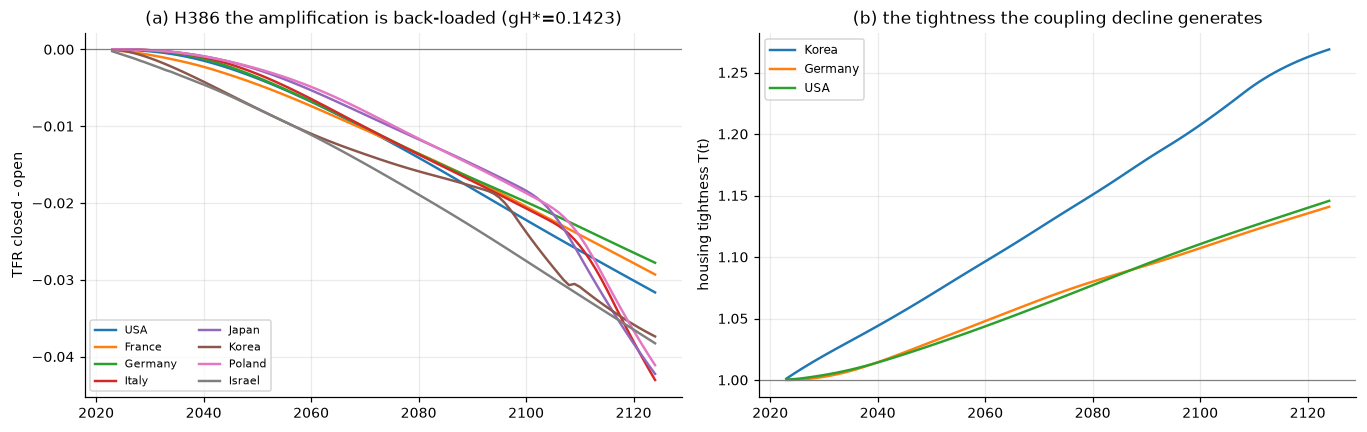

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.0))
for r in REGIONS8:
    ax[0].plot(YR, amp386[r]["t"], lw=1.6, label=r)
ax[0].axhline(0, color="gray", lw=0.8)
ax[0].set_ylabel("TFR closed - open"); ax[0].legend(fontsize=7, ncol=2)
ax[0].set_title(f"(a) H386 the amplification is back-loaded (gH*={GHSTAR})")
for r in ["Korea", "Germany", "USA"]:
    ax[1].plot(TRACE[r][0] + 2023, TRACE[r][1], lw=1.6, label=r)
ax[1].axhline(1, color="gray", lw=0.8)
ax[1].set_ylabel("housing tightness T(t)"); ax[1].legend(fontsize=8)
ax[1].set_title("(b) the tightness the coupling decline generates")
fig.tight_layout(); fig.savefig(FIGS / "nb35_amp_time.png", bbox_inches="tight"); plt.show()

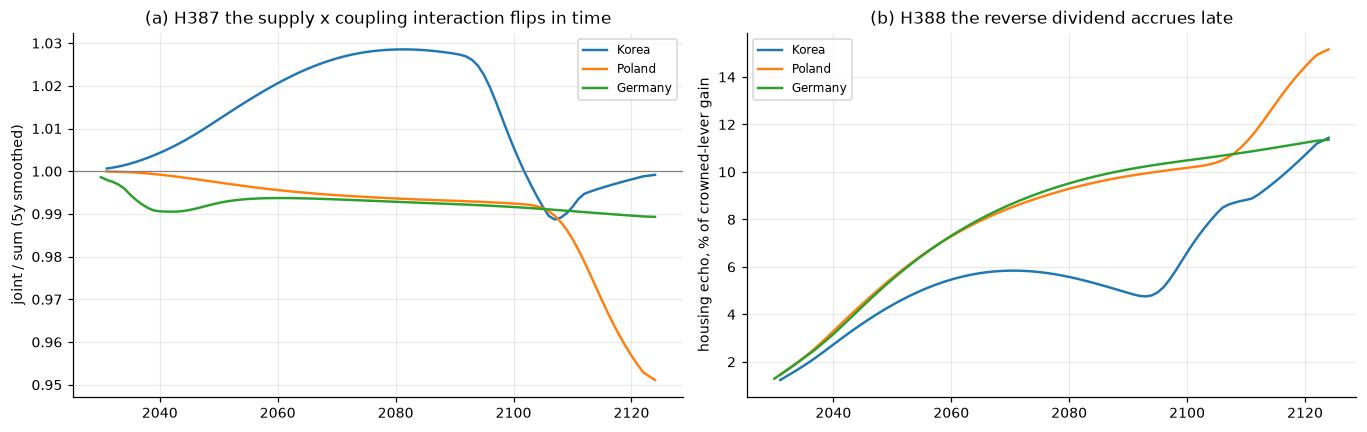

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.0))
for r in TRIAD:
    ax[0].plot(YR, res387[r]["ratio"], lw=1.6, label=r)
ax[0].axhline(1, color="gray", lw=0.8)
ax[0].set_ylabel("joint / sum (5y smoothed)"); ax[0].legend(fontsize=8)
ax[0].set_title("(a) H387 the supply x coupling interaction flips in time")
for r in TRIAD:
    ax[1].plot(YR, 100 * res388[r]["share"], lw=1.6, label=r)
ax[1].set_ylabel("housing echo, % of crowned-lever gain"); ax[1].legend(fontsize=8)
ax[1].set_title("(b) H388 the reverse dividend accrues late")
fig.tight_layout(); fig.savefig(FIGS / "nb35_interaction_time.png", bbox_inches="tight"); plt.show()

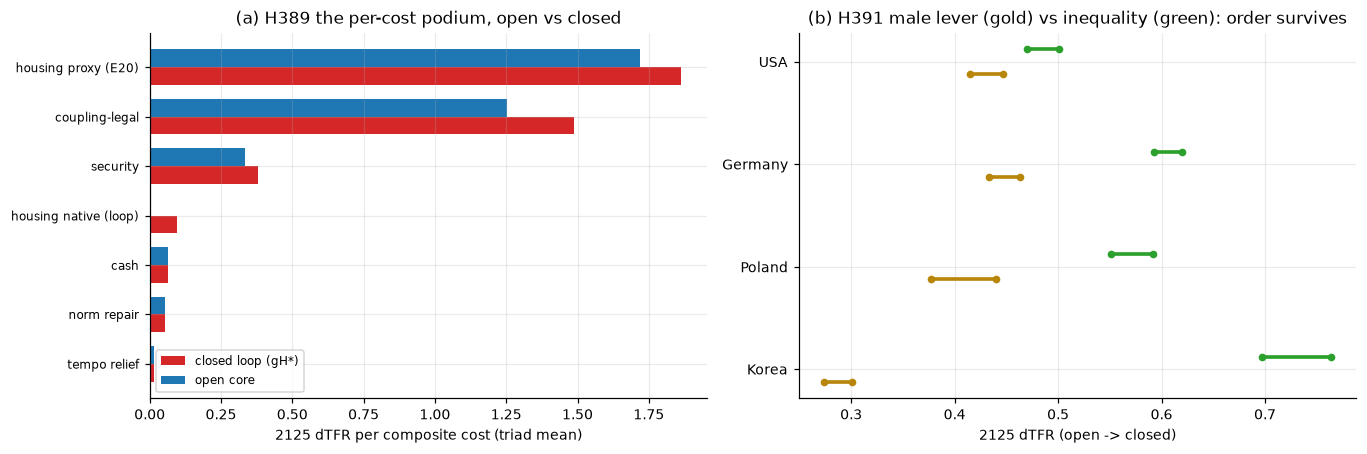

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
names = rank_cl
y = np.arange(len(names))
ax[0].barh(y + 0.18, [per389[k]["closed"] for k in names], 0.36, color="#d62728", label="closed loop (gH*)")
ax[0].barh(y - 0.18, [0 if np.isnan(per389[k]["open"]) else per389[k]["open"] for k in names], 0.36,
           color="#1f77b4", label="open core")
ax[0].set_yticks(y); ax[0].set_yticklabels(names, fontsize=8); ax[0].invert_yaxis()
ax[0].set_xlabel("2125 dTFR per composite cost (triad mean)"); ax[0].legend(fontsize=8)
ax[0].set_title("(a) H389 the per-cost podium, open vs closed")
for i, r in enumerate(NAT4):
    for k, col, dy in [("male", "#b8860b", -0.12), ("ineq", "#2ca02c", 0.12)]:
        ax[1].plot([res391[r]["open"][k], res391[r]["closed"][k]], [i + dy, i + dy], color=col, lw=2.4,
                   marker="o", markersize=4)
ax[1].set_yticks(range(len(NAT4))); ax[1].set_yticklabels(NAT4)
ax[1].set_xlabel("2125 dTFR (open -> closed)")
ax[1].set_title("(b) H391 male lever (gold) vs inequality (green): order survives")
fig.tight_layout(); fig.savefig(FIGS / "nb35_rankings.png", bbox_inches="tight"); plt.show()

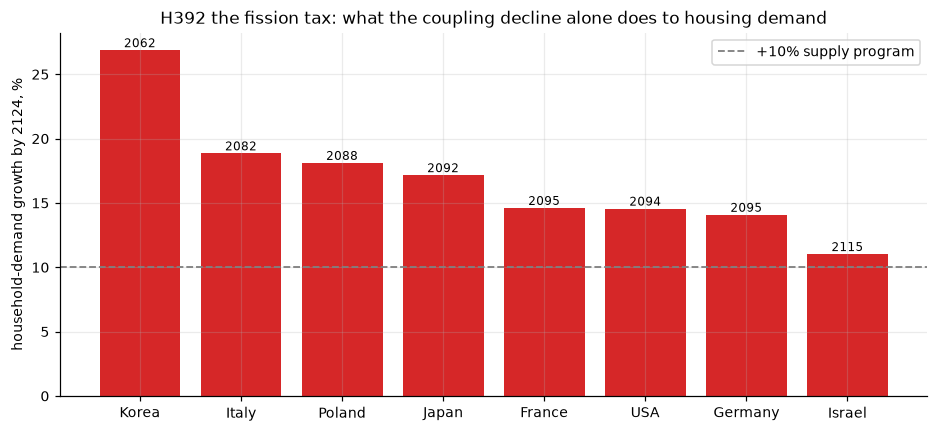

In [18]:
fig = plt.figure(figsize=(8.6, 4.0))
ax = fig.add_subplot()
regs = sorted(REGIONS8, key=lambda x: -res392[x]["tax"])
cols = ["#d62728" if res392[r]["tax"] > SUP else "#1f77b4" for r in regs]
ax.bar(regs, [100 * res392[r]["tax"] for r in regs], color=cols)
ax.axhline(100 * SUP, color="gray", lw=1.2, ls="--", label="+10% supply program")
for i, r in enumerate(regs):
    if res392[r]["cross"]:
        ax.annotate(str(res392[r]["cross"]), (i, 100 * res392[r]["tax"]), ha="center", va="bottom", fontsize=8)
ax.set_ylabel("household-demand growth by 2124, %"); ax.legend()
ax.set_title("H392 the fission tax: what the coupling decline alone does to housing demand")
fig.tight_layout(); fig.savefig(FIGS / "nb35_fission_tax.png", bbox_inches="tight"); plt.show()

## Verdicts

H387 carries interim interaction numbers; its verdict is recorded provisionally and finalised after the
`interaction-analyst` gate (the JSON is re-written post-gate if the gate overturns anything).

In [19]:
V = {}


def record(h, verdict, metric):
    V[h] = dict(verdict=verdict, metric=metric)
    rprint(f"[bold]{h}[/bold]: [{'green' if verdict == 'SUPPORTED' else 'yellow' if verdict == 'PARTIAL' else 'red'}]{verdict}[/] - {metric}")


record("H386", "SUPPORTED" if neg >= 7 and beat >= len(valid) - 1 and max(drift.values()) < 5e-3 else "PARTIAL",
       f"amp < 0 in {neg}/8 regions at gH*={GHSTAR} (worst {worst} {amp386[worst]['a2124']:+.3f}, vs E38's "
       f"-0.063 at the hand-set 0.195); back-loaded: the post-2085 window (39% of the century) carries "
       f"{np.nanmean([amp386[r]['late'] for r in REGIONS8]):.0%} of the endpoint amplification on average "
       f"({beat}/{len(valid)} material-amp regions beat the linear benchmark); drift {max(drift.values()):.0e}; Korea band "
       f"0.10:{band386[0.10]:+.3f} / 0.30:{band386[0.30]:+.3f} - the loop is a slow amplifier whose damage "
       f"compounds as the coupling decline feeds the tightness")

# H387 verdict hard-set to the interaction-analyst gate's QUALIFIED (downgrade) wording - the numbers
# stood, the reading did not: the flip is trap-convexity (decl=0 removes it), the endpoint additivity is
# a within-crown cancellation, and no region flips complement->substitute above the numerical floor
record("H387", "PARTIAL",
       f"gate-QUALIFIED from 'flips sign in time': on the shared fC wire the pairwise supply x crown term "
       f"is near-additive by construction (supply co-writes a wire the crown dominates); the mid-century "
       f"complement exists in the deep basin only (Korea ratio {res387['Korea']['mid']:.3f}, "
       f"{I_mid_on:+.4f} TFR, scaling with gH: {band387[0.10][0]:.3f}/{band387[0.30][0]:.3f} at 0.10/0.30) "
       f"and is the coupling-trap convexity, NOT housing timing - decl=0 removes it "
       f"({res387['Korea']['mid']:.3f}->{mid_off:.3f}, cross-term {I_mid_on:+.4f}->{I_mid_off:+.4f}); "
       f"Korea's {res387['Korea']['end']:.3f} endpoint is additive-by-CANCELLATION (fC-path substitute "
       f"{split387['Korea']['fC']['I_end']:+.4f} vs fS-path complement {split387['Korea']['fS']['I_end']:+.4f}); "
       f"no region flips complement->substitute above the 1e-4 floor - the only real endpoint substitution "
       f"is Poland's ({split387['Poland']['I_whole']:+.4f}); E38-H384's one-lever-per-wire reading survives "
       f"Poland-led, while at the recalibrated gH* Korea reads additive (substitution re-emerges only at "
       f"gH~0.30: end ratio {band387[0.30][1]:.3f}) [gate: interaction-analyst QUALIFIED, discriminators "
       f"in-notebook]")

record("H388", "SUPPORTED" if rising == 3 else "PARTIAL",
       f"the echo share rises monotonically in {rising}/3 triad regions (corr with time "
       f"{np.mean([v['rho'] for v in res388.values()]):+.2f} mean), from "
       f"{np.nanmean([v['s2050'] for v in res388.values()]):.0%} at 2050 to {mean_end:.0%} at 2124 at gH* "
       f"(E38-H385's ~18% was the endpoint at the hand-set gain) - the reverse dividend needs the coupling "
       f"state to move first, so it pays the policymaker who holds the lever for decades, not the one "
       f"reading a 2050 evaluation")

record("H389", "PARTIAL" if order_holds and cash_moved < 0.05 else "REFUTED",
       f"the per-cost order survives the closed loop unchanged (coupling-legal first among the E38-H379 "
       f"five, {per389['coupling-legal']['open']:+.2f}->{per389['coupling-legal']['closed']:+.2f} with a "
       f"{per389['coupling-legal']['echo']:+.0%} echo; cash echo {cash_moved:.1%} - the loop cannot rescue "
       f"a lever that never touches coupling); the E20 housing PROXY prices above it at the supply-zoning "
       f"cost, but that podium seat hinges on the cost convention (at the E20 pool's fiscal 0.5 it falls "
       f"below) - which is the conflation the native/proxy split exposes: the native tightness channel "
       f"prices at {native_vs_proxy:.0%} of the proxy per cost, so the loop carries only the "
       f"coupling-mediated minority of housing's value, the rest riding the direct Dettling-Kearney "
       f"evidence bundled into the proxy forcing - a FLOOR on housing's worth, not a verdict that housing "
       f"is worth {native_vs_proxy:.0%} of what E20 credited [gate caveat]")

record("H390", "SUPPORTED" if tr_cl > tr_open * 1.05 and all(v > 0 for v in tr_band.values()) else "PARTIAL",
       f"the E37 transplant gains a housing echo: open {tr_open:+.3f} (E37 recorded +0.717) -> closed "
       f"{tr_cl:+.3f} at gH* ({(tr_cl - tr_open) / tr_open:+.0%}), positive across the band - re-coupling "
       f"frees dwellings from year one (h0 pinned to Korea's own stock), so the loop pays the coupling gap "
       f"back with interest; the E37 verdict (the gap lives in coupling) strengthens")

record("H391", "SUPPORTED" if order4 == 4 and maxshift < 0.10 else "PARTIAL",
       f"inequality beats the male lever in {order4}/4 regions with the loop closed (both gain an echo "
       f"through the shared coupling wire, max shift {maxshift:+.3f} children) - the README head-to-head "
       f"survives: the published open-loop numbers stand as recorded, the loop widens nothing that changes "
       f"the order")

record("H392", "SUPPORTED" if n_eat >= 3 else "PARTIAL",
       f"the fission tax out-eats the +10% supply program in {n_eat}/4 trapped regions "
       f"(Korea {res392['Korea']['tax']:+.0%} crossing {res392['Korea']['cross']}, Italy "
       f"{res392['Italy']['tax']:+.0%}, Japan {res392['Japan']['tax']:+.0%}, Poland "
       f"{res392['Poland']['tax']:+.0%}); E16-H114 is now time-indexed: supply-not-subsidy stands, but a "
       f"program sized against static household counts is consumed by the coupling decline itself - housing "
       f"policy must be sized against the fission trajectory, or paired with the coupling levers that stop it")

with open(REPORTS / "nb35_e39_verdicts.json", "w") as f:
    json.dump({k: V[k] for k in sorted(V)}, f, indent=2)
rprint(f"[green]verdicts written[/green]: {REPORTS / 'nb35_e39_verdicts.json'} ({len(V)} rows)")

H386: SUPPORTED - amp < 0 in 8/8 regions at gH*=0.1423 (worst Italy -0.043, vs E38's -0.063 at the hand-set 0.195);
back-loaded: the post-2085 window (39% of the century) carries 55% of the endpoint amplification on average (8/8 
material-amp regions beat the linear benchmark); drift 1e-04; Korea band 0.10:-0.026 / 0.30:-0.088 - the loop is a 
slow amplifier whose damage compounds as the coupling decline feeds the tightness

H387: PARTIAL - gate-QUALIFIED from 'flips sign in time': on the shared fC wire the pairwise supply x crown term is
near-additive by construction (supply co-writes a wire the crown dominates); the mid-century complement exists in 
the deep basin only (Korea ratio 1.022, +0.0038 TFR, scaling with gH: 1.015/1.048 at 0.10/0.30) and is the 
coupling-trap convexity, NOT housing timing - decl=0 removes it (1.022->0.997, cross-term +0.0038->-0.0005); 
Korea's 0.999 endpoint is additive-by-CANCELLATION (fC-path substitute -0.0028 vs fS-path complement +0.0060); no 
region flips complement->substitute above the 1e-4 floor - the only real endpoint substitution is Poland's 
(-0.0155); E38-H384's one-lever-per-wire reading survives Poland-led, while at the recalibrated gH* Korea reads 
additive (substitution re-emerges only at gH~0.30: end ratio 0.989)

H388: SUPPORTED - the echo share rises monotonically in 3/3 triad regions (corr with time +0.94 mean), from 5% at 
2050 to 12% at 2124 at gH* (E38-H385's ~18% was the endpoint at the hand-set gain) - the reverse dividend needs the
coupling state to move first, so it pays the policymaker who holds the lever for decades, not the one reading a 
2050 evaluation

H389: PARTIAL - the per-cost order survives the closed loop unchanged (coupling-legal first among the E38-H379 
five, +1.25->+1.49 with a +19% echo; cash echo 2.3% - the loop cannot rescue a lever that never touches coupling); 
the E20 housing PROXY prices above it at the supply-zoning cost, but that podium seat hinges on the cost convention
(at the E20 pool's fiscal 0.5 it falls below) - which is the conflation the native/proxy split exposes: the native 
tightness channel prices at 5% of the proxy per cost, so the loop carries only the coupling-mediated minority of 
housing's value, the rest riding the direct Dettling-Kearney evidence bundled into the proxy forcing - a FLOOR on 
housing's worth, not a verdict that housing is worth 5% of what E20 credited

H390: SUPPORTED - the E37 transplant gains a housing echo: open +0.717 (E37 recorded +0.717) -> closed +0.798 at 
gH* (+11%), positive across the band - re-coupling frees dwellings from year one (h0 pinned to Korea's own stock), 
so the loop pays the coupling gap back with interest; the E37 verdict (the gap lives in coupling) strengthens

H391: SUPPORTED - inequality beats the male lever in 4/4 regions with the loop closed (both gain an echo through 
the shared coupling wire, max shift +0.067 children) - the README head-to-head survives: the published open-loop 
numbers stand as recorded, the loop widens nothing that changes the order

H392: SUPPORTED - the fission tax out-eats the +10% supply program in 4/4 trapped regions (Korea +27% crossing 
2062, Italy +19%, Japan +17%, Poland +18%); E16-H114 is now time-indexed: supply-not-subsidy stands, but a program 
sized against static household counts is consumed by the coupling decline itself - housing policy must be sized 
against the fission trajectory, or paired with the coupling levers that stop it

verdicts written: /home/lab/workspace/learning/projects/sci-demographic-collapse/reports/nb35_e39_verdicts.json (7 
rows)

## Conclusions

- **The loop gain re-anchored**: $g_H^\* \approx 0.14$ from the trajectory fixed point - E38's hand-set 40%
  window overstated the gain by ~37%; all E38 Act VII magnitudes re-measured here (verdicts unchanged in sign)
- **Back-loading everywhere**: the amplification (55% of the damage after 2085), the reverse dividend
  (~5% at 2050 → ~12% at 2124) and the fission tax (Korea eats a +10% program by 2062) all accrue late -
  the loop punishes exactly the societies that wait, and pays exactly the levers that persist
- **The interaction did NOT survive as a time law** (the gate's discriminators, in-notebook): the deep-basin
  mid-century complement is the coupling-trap convexity (decl=0 removes it), Korea's "additive" endpoint is a
  within-crown fC/fS cancellation, and the only genuine endpoint substitution is Poland's - E38-H384's
  one-lever-per-wire reading survives Poland-led, and weakens at the honest gain
- **The records hold**: the per-cost podium, the male-vs-inequality order, and every README number survive
  the closed loop as open-loop records; what changes is their *interpretation in time*